In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Dataset Loading:

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64
)

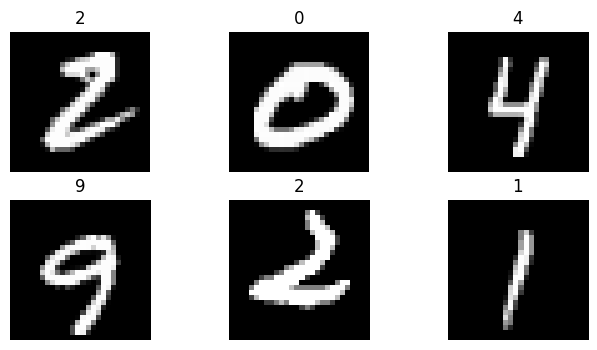

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(labels[i].item())
    plt.axis('off')
plt.show()

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)

        return x

In [ ]:
model = CNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3):

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0140
Epoch 2, Loss: 0.0475
Epoch 3, Loss: 0.0172


In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1) #softmax

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 98.85


# CIFAR-10 Image Classification

Data Loading:

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

In [ ]:
from torchvision import models

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for param in model.parameters():
    param.requires_grad = False



model.fc = nn.Linear(model.c.in_features, 10)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/5] Loss: 1.7289
Epoch [2/5] Loss: 1.6025
Epoch [3/5] Loss: 1.5852
Epoch [4/5] Loss: 1.5677
Epoch [5/5] Loss: 1.5694


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 45.59%


# Some Experiments:

In [ ]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64*6*6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.fc2(x)

        return x

In [ ]:
custom_cnn = CustomCNN()

In [ ]:
print(custom_cnn)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
for name, param in custom_cnn.named_parameters():
    print(name)

conv1.weight
conv1.bias
conv2.weight
conv2.bias
fc1.weight
fc1.bias
fc2.weight
fc2.bias


In [ ]:
for param in custom_cnn.conv1.parameters():
    param.requires_grad = False

In [ ]:
for param in custom_cnn.parameters():
    param.requires_grad = False

for param in custom_cnn.fc2.parameters():
    param.requires_grad = True

# CNN Visualizaiton:

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("/content/3542.webp").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = transform(image).unsqueeze(0)

In [ ]:
model = models.resnet18(pretrained=True)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
conv1 = model.conv1

In [ ]:
with torch.no_grad():
    feature_maps = conv1(img)

In [ ]:
feature_maps.shape

torch.Size([1, 64, 112, 112])

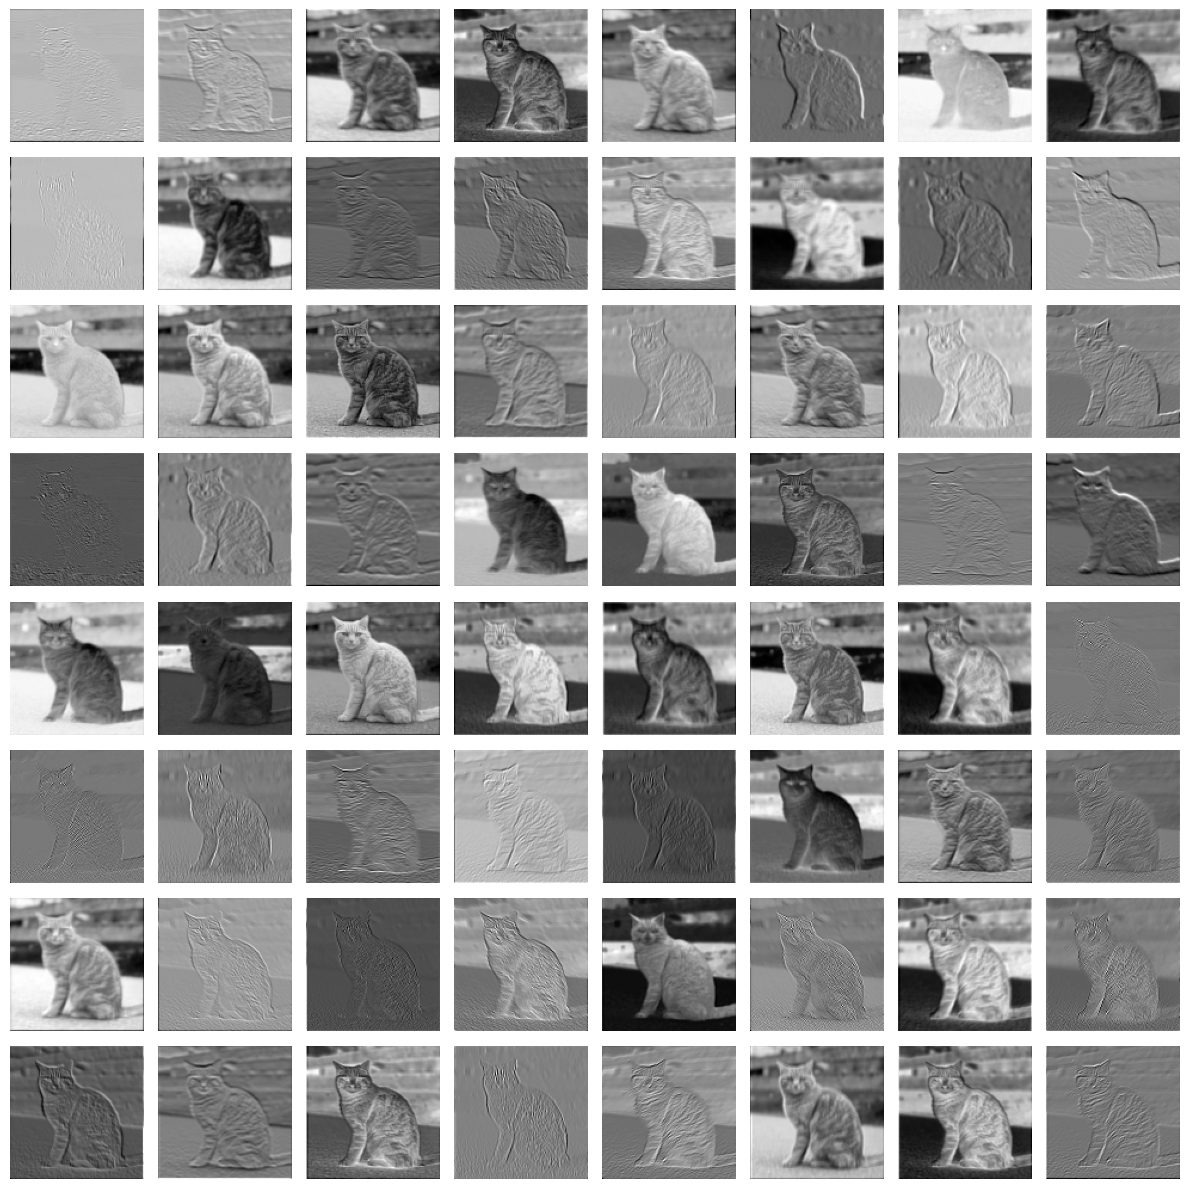

In [ ]:
feature_maps = feature_maps.squeeze(0)

plt.figure(figsize=(12,12))

for i in range(64):

    plt.subplot(8, 8, i + 1)
    plt.imshow(feature_maps[i].cpu(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1199.5), np.float64(1199.5), np.float64(-0.5))

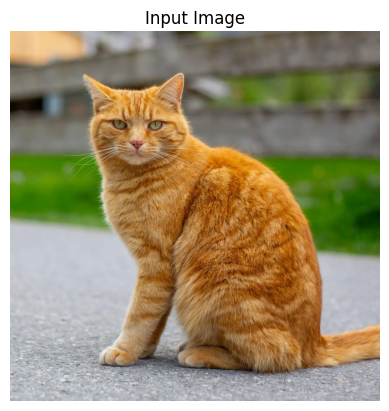

In [ ]:
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

GradCam Demo:

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image

In [ ]:
def preprocess_image(image_path):

    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    img_tensor = transform(image).unsqueeze(0)

    return image, img_tensor

In [ ]:
def generate_gradcam(model, img_tensor, target_layer):

    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0]

    # register hooks
    target_layer.register_forward_hook(forward_hook)
    target_layer.register_backward_hook(backward_hook)

    # forward pass
    output = model(img_tensor)
    pred_class = output.argmax(dim=1)

    # backward pass
    model.zero_grad()
    output[0, pred_class].backward()

    # compute weights
    pooled_gradients = torch.mean(gradients, dim=[0,2,3])

    for i in range(activations.shape[1]):
        activations[:,i,:,:] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= torch.max(heatmap)

    return heatmap.detach().numpy(), pred_class.item()

In [ ]:
def overlay_gradcam(original_image, heatmap):

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    image_np = np.array(original_image.resize((224,224)))

    superimposed = heatmap * 0.4 + image_np

    return np.uint8(superimposed)

In [ ]:
model = models.resnet18(pretrained=True)
model.eval()
target_layer = model.layer4[-1].conv2

In [ ]:
image, img_tensor = preprocess_image("/content/tiger_cat_image.jpg")

heatmap, pred_class = generate_gradcam(model, img_tensor, target_layer)

result = overlay_gradcam(image, heatmap)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

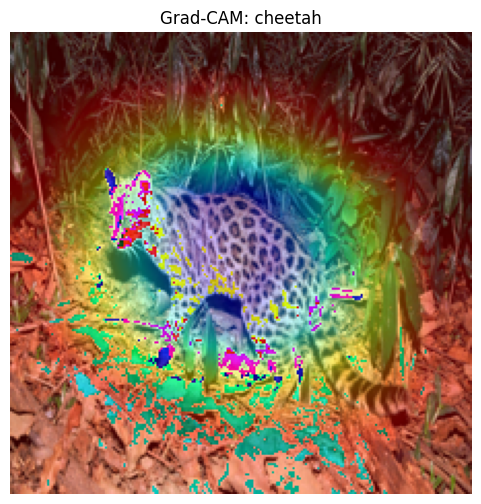

In [ ]:
import urllib.request

classes = urllib.request.urlopen(
"https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
).read().decode("utf-8").splitlines()




label = classes[pred_class]


plt.figure(figsize=(6,6))
plt.imshow(result)

plt.title(f"Grad-CAM: {label}")

plt.axis("off")